# 99 Original Final Model Evaluation
**Note:** In all but the last set of LSTM model notebooks, we were using the wrong version of the dataset. This final model evaluation will be focused on the last model that we tested after correcting for the data. Specifically, we will be evaluating our sliding window model not only with the current test set, but also new data that we obtain from yfinance in 2025.

**Note 2:** This notebook is essentially the same as the actual Final Model Evaluation notebook, but everything past the "**(OLD AND USING THE INCORRECT DATA SPLITS) Evaluating Final Model Performance with the Original Test Set**" section is using old data. We kept that section there just to keep our measurement metrics in case we want to revisit them in the future.

## Imports

In [670]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.optimizers import SGD
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Getting S&P500 Table Data

In [3]:
sp500_tables = pd.read_csv('../SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [4]:
# Loading in stock data
data = pd.read_csv("../SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [5]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [6]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Deriving multiple different features and outcome variables we can use in our model.

In [7]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [8]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [9]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [10]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [12]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features
Of the features we created, we select only the ones that we intend on using.

In [13]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [14]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [15]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [16]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [17]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [18]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [19]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [20]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [21]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

## Creating Dummy Variables for GICS Sector

In [22]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [23]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (453625, 12) 



In [24]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [25]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (453625, 36)


# Final LSTM Sliding Model (896/3/1 Train/Val/Test Split)
Our final chosen model involves using a training, validation, and test split of 896/3/1 days, respectively. Additionally, this model consists of a sequence length of 50 days, only 1 LSTM layer (128 units) and 1 dropout layer, and it will slide across our entire dataset. We have already tested the results of this model in the previous notebook, but we'll ultimately download more data from 2025 as our final test set to truly evaluate model performance.

## Generating X continuous series sequences and Y continuous labels for LSTM model
Here, we generate the correct X series sequences and respective Y continuous labels, ordered first by the date, and then by the ticker.

The following is the **corrected** function used to create our X and Y sequences in the LSTM model, with the "new addition" code at the bottom re-ordering the data first by date, and then by ticker:

In [540]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    num_tickers = df['Ticker'].nunique()
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)

    # NEW ADDITION: Correctly re-ordering data first by the date, and THEN by the ticker
    indices_by_date_then_ticker = np.arange(X.shape[0]).reshape((num_tickers, -1)).flatten('F')
    X = X[indices_by_date_then_ticker]
    Y = Y[indices_by_date_then_ticker]
    
    return X, Y

In [718]:
# Creating sequences for LSTM model
seq_length = 50
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [721]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (430350, 50, 32)
Shape of Y_data_smaller: (430350,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 50
Number of sequences assuming the above seq_length: 906
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 430350
Total number of data sequences achieved: 430350


## Defining functions for splitting the dataset and building/compiling the LSTM model

We use the following function to constantly generate new training, validation, and test data splits as we slide our window:

In [722]:
# Defining function to split sequence data into train, val, test splits with split size (in terms of # of days)
def train_val_test_seq_split(X_window, Y_window, num_tickers, train_size, val_size, test_size):
    X_data = X_window.copy()
    Y_data = Y_window.copy()

    if (X_data.shape[0]/num_tickers) != (train_size + val_size + test_size):
        print("Train + val + test sizes do not much number of dates")
        return None

    X_train = X_data[:(num_tickers * train_size)]
    Y_train = Y_data[:(num_tickers * train_size)]
    X_val = X_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    Y_val = Y_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    X_test = X_data[(num_tickers * (train_size + val_size)):]
    Y_test = Y_data[(num_tickers * (train_size + val_size)):]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

We use the following function to rebuild, compile, and run our LSTM model for each sliding train/val/test window:

In [723]:
# Defining a function to create the LSTM model for sliding train, val, and test windows
def build_LSTM_model_slide(seq_length,
                     num_features,
                     n_classes,
                     LSTM_units=256,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=LSTM_units, return_sequences=False, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

## (Initial Window) Running the LSTM model with the initial train/val/test window
We want to test our model performance for this first window, and then we can move onto the next windows in the following step.

In [724]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [725]:
# Defining initial variables for the first window
num_sequences_per_ticker = unique_dates - seq_length + 1  # unique_dates is from above
window_size_initial = 900  # 896 + 3 + 1
train_window = 896
val_window = 3
test_window = 1

# Getting the initial windows for X and Y
X_window_initial = X_data_smaller[:(unique_tickers * window_size_initial)]
Y_window_initial = Y_data_smaller[:(unique_tickers * window_size_initial)]

# Splitting the data into train, val, and test sets
X_train_init, Y_train_init, X_val_init, Y_val_init, X_test_init, Y_test_init = train_val_test_seq_split(
    X_window_initial, Y_window_initial, unique_tickers, train_window, val_window, test_window)

print("X_train_init shape:", X_train_init.shape)
print("Y_train_init shape:", Y_train_init.shape)
print("X_val_init shape:", X_val_init.shape)
print("Y_val_init shape:", Y_val_init.shape)
print("X_test_init shape:", X_test_init.shape)
print("Y_test_init shape:", Y_test_init.shape)

X_train_init shape: (425600, 50, 32)
Y_train_init shape: (425600,)
X_val_init shape: (1425, 50, 32)
Y_val_init shape: (1425,)
X_test_init shape: (475, 50, 32)
Y_test_init shape: (475,)


In [726]:
# Building the initial model
model_LSTM_slide_initial = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
model_LSTM_slide_initial.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,819 (323.51 KB)

 Trainable params: 82,819 (323.51 KB)

 Non-trainable params: 0 (0.00 B)

In [727]:
# Fitting the model
model_LSTM_slide_initial_fit = model_LSTM_slide_initial.fit(
    x = X_train_init,
    y = Y_train_init,
    validation_data = [X_val_init, Y_val_init],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1)

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.3719 - loss: 1.0910 - val_accuracy: 0.3726 - val_loss: 1.0718
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 160s 96ms/step - accuracy: 0.3964 - loss: 1.0752 - val_accuracy: 0.4470 - val_loss: 1.0552
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 157s 94ms/step - accuracy: 0.4027 - loss: 1.0720 - val_accuracy: 0.4828 - val_loss: 1.0496
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 150s 90ms/step - accuracy: 0.4091 - loss: 1.0697 - val_accuracy: 0.4905 - val_loss: 1.0429
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 146s 88ms/step - accuracy: 0.4124 - loss: 1.0680 - val_accuracy: 0.5088 - val_loss: 1.0400
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 148s 89ms/step - accuracy: 0.4155 - loss: 1.0669 - val_accuracy: 0.5144 - val_loss: 1.0370
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 144s 87ms/step - accuracy: 0.4172 - loss: 1.0658 - val_accuracy: 0.5179 - val_loss: 1.0319
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 146s 88ms/step - accuracy: 

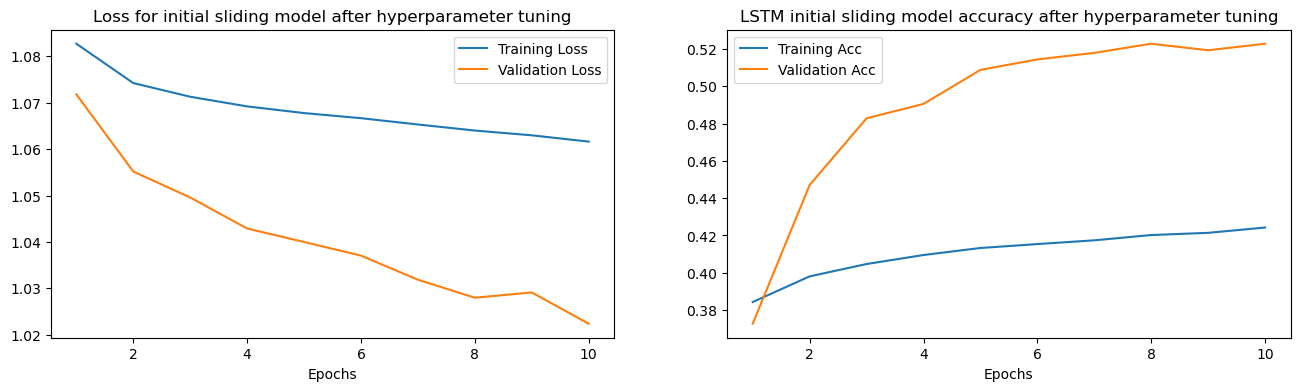

In [728]:
# Plotting the loss on the first subplot
hist_sl_init = model_LSTM_slide_initial_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_sl_init['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for initial sliding model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_sl_init['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM initial sliding model accuracy after hyperparameter tuning')
plt.show()

In [729]:
print("Final training accuracy:", hist_sl_init['accuracy'][-1])
print("Final validation accuracy:", hist_sl_init['val_accuracy'][-1])

Final training accuracy: 0.4242246150970459
Final validation accuracy: 0.5228070020675659


The training and validation accuracies are comparable to before, which gives us at least some confidence that this model works reasonably well.

In [730]:
# Evaluating the model against X_test and Y_test
model_LSTM_slide_initial.evaluate(X_test_init, Y_test_init)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1472 - loss: 1.1384


[1.1323004961013794, 0.1621052622795105]

The test accuracy here looks extremely poor. However, analyzing the stock market on this date reveals that this particular day (12/20/24) was incredibly bullish, so our model may not have been able to capture that trend. We can analyze our confusion matrix to confirm this observation.

### Plotting a confusion matrix for the test predictions

In [732]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test_init,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[ 14,   0,   9],
       [ 45,   0,  13],
       [329,   2,  63]])

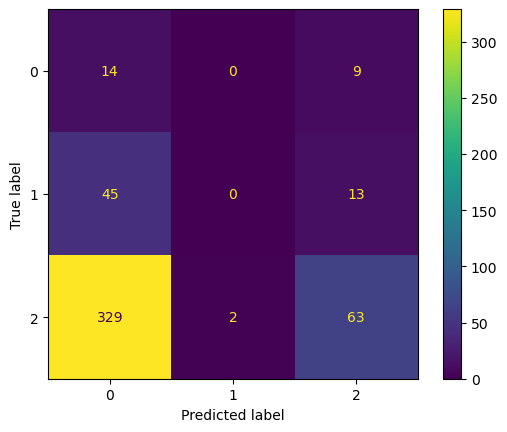

In [733]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test_init,
    y_pred=Y_test_pred,
    labels=None
)

As expected, because of how bullish this day was, most of the stocks were positive, and our model was unable to determine that. Even with a prediction threshold, it's unlikely that our model will be able to tell the difference.

### Further analyses with prediction threshold
We changed the prediction threshold from 0.4 to 0.9, but found that a threshold of 0.5 worked the best.

In [734]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Getting the Y_test_pred_thresh
Y_test_pred_thresh = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_thresh = np.where(Y_test_pred_thresh[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_thresh[:, 2] > pred_threshold, 2, 1))

# Getting the confusion matrix with the threshold
cf_thresh = confusion_matrix(
    Y_test_init,
    Y_test_pred_thresh
)

cf_thresh

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[  6,  12,   5],
       [ 18,  36,   4],
       [142, 239,  13]])

Once again, we see see that a prediction threshold doesn't matter much, as the market so heavily bullish on this day. Nevertheless, let's continue our sliding window (for the remaining 6 days in our dataset) and see what results we get.

## (Sliding Windows) Re-training the model as we slide the window for new data dates
We now slide the window over by one day, but keeping the 900 window size the same. We keep repeating until we run out of data (7 windows total including the initial window (we explain how we got this number below)).

In [735]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [755]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting the window size to slide over and other initial parameters
first_slide_day = 1
slide_amount = 1  # Amount to slide each window
window_size_slide = 900
train_window_slide = 896
val_window_slide = 3
test_window_slide = 1

# Getting a dictionary of different metrics
metrics_dict = {}

# Looping over the window range as we slide the window
# for start_day_num in range(first_slide_day, 3, slide_amount):
for start_day_num in range(first_slide_day, num_sequences_per_ticker - window_size_slide + 1, slide_amount):

    # Getting the windows for X and Y
    X_window = X_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]
    Y_window = Y_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]

    # Splitting data into train, val, and test sets
    X_train_sl, Y_train_sl, X_val_sl, Y_val_sl, X_test_sl, Y_test_sl = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window_slide, val_window_slide, test_window_slide)

    # Building the model from scratch
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
    
    # Fitting the model again for each slide
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train_sl,
        y = Y_train_sl,
        validation_data = [X_val_sl, Y_val_sl],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)
    
    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    train_accuracy_sl = hist_sl['accuracy'][-1]
    val_accuracy_sl = hist_sl['val_accuracy'][-1]

    # Getting the test accuracy
    Y_test_sl_pred = model_LSTM_slide.predict(X_test_sl)  # Softmax predictions
    Y_test_sl_pred_no_thresh = np.argmax(Y_test_sl_pred, axis = 1)  # Argmax of predictions
    test_accuracy_sl = (Y_test_sl_pred_no_thresh == Y_test_sl).sum() / len(Y_test_sl)

    # Getting the no threshold confusion matrix using Y_test_sl and Y_test_sl_pred
    cf_no_thresh = confusion_matrix(
        Y_test_sl,
        Y_test_sl_pred_no_thresh)

    # Creating and appending metrics list to metrics_dict
    metrics_dict[start_day_num] = [train_accuracy_sl, val_accuracy_sl, test_accuracy_sl, cf_no_thresh]

    # Setting different prediction thresholds and getting the Y_test_sl_pred_thresh confusion matrix for each
    thresholds_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
    for threshold in thresholds_list:
        Y_test_sl_pred_thresh = np.where(Y_test_sl_pred[:, 0] > threshold, 0,
                                     np.where(Y_test_sl_pred[:, 2] > threshold, 2, 1))
        
        # Getting the confusion matrix for this threshold and appending it to the list in the dictionary
        cf_thresh = confusion_matrix(
            Y_test_sl,
            Y_test_sl_pred_thresh)
        metrics_dict[start_day_num].append(cf_thresh)
    

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 162s 97ms/step - accuracy: 0.3766 - loss: 1.0894 - val_accuracy: 0.3340 - val_loss: 1.0577
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 163s 98ms/step - accuracy: 0.3980 - loss: 1.0750 - val_accuracy: 0.3768 - val_loss: 1.0509
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 164s 98ms/step - accuracy: 0.4049 - loss: 1.0713 - val_accuracy: 0.4119 - val_loss: 1.0435
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 153s 92ms/step - accuracy: 0.4092 - loss: 1.0693 - val_accuracy: 0.4189 - val_loss: 1.0422
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 154s 93ms/step - accuracy: 0.4123 - loss: 1.0678 - val_accuracy: 0.4316 - val_loss: 1.0398
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 162s 97ms/step - accuracy: 0.4149 - loss: 1.0665 - val_accuracy: 0.4295 - val_loss: 1.0389
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 159s 96ms/step - accuracy: 0.4168 - loss: 1.0655 - val_accuracy: 0.4309 - val_loss: 1.0383
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 159s 96ms/step - accuracy: 

In [782]:
# Printing the full metrics_dict just to see it:
metrics_dict

{1: [0.42536184191703796,
  0.4343859553337097,
  0.5557894736842105,
  array([[  6,   8,  27],
         [  5, 116,  94],
         [  7,  70, 142]]),
  array([[  7,  19,  15],
         [  3, 153,  59],
         [ 10, 118,  91]]),
  array([[  2,  37,   2],
         [  2, 194,  19],
         [  2, 193,  24]]),
  array([[  0,  41,   0],
         [  0, 214,   1],
         [  0, 216,   3]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 217,   2]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 218,   1]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]])],
 2: [0.4266353249549866,
  0.4161403477191925,
  0.2905263157894737,
  array([[  6,   4,   4],
         [  4, 104,  16],
        

For clarity on the code below, our train day for the first result below starts on day 51 because:
1) This is the second time we're training this model (the previous, first experiment had a training day start of day 50), and
2) Our sequence length of 50 requires each series of data to include the current day and the previous 49 days (hence why our previous training day start was day 50).

The combined reasons above ultimately mean that we have to slide a 900-day window across 955 - 50 + 1 = 906 days, starting on day 50. Thus, our range of days is from day 50 to day 955, with 7 possible slides. The first window (in our previous experiment) started on Day 50 and went to Day 949 (Day 50 to Day 945 were the 896 (945 - 50 + 1 = 896) days of training data, Day 946 to Day 948 were the 3 validation days, and Day 949 was the test day). Similarly, the final, seventh window started on Day 56 and went to Day 955, which is indeed the last day in our data.

**Technically, the reason we have 955 days in the dataset is because we used the first 50 days for one of our features - SMA 50 (with previous day prices) - not to be confused with our sequence length of 50. Our original dataset came with 1,005 days of data; thus, our "starting day" of 50 is really a starting day of 100. However, for consistency purposes, we'll keep day 50 as our "true" start date.*

In [791]:
# Getting overall confusion matrix with 0.45 threshold
cf_overall_0_45 = np.zeros((3, 3))

# Printing the train, val, test accuracies for each window, along with the confusion matrices with a threshold of 0.45
for start_day, metrics in metrics_dict.items():

    # Getting actual days of when train/val/test data started and ended
    true_start_day = start_day + 50
    train_val_end = true_start_day + 898
    test_day = train_val_end + 1
    print(str(start_day) + ". Train/val from days " + str(true_start_day) + " to " + str(train_val_end) +
          "; test day on " + str(test_day) + ":")

    # Getting train, val, and test accuracies
    train_acc_rounded = round(metrics[0], 4)
    val_acc_rounded = round(metrics[1], 4)
    test_acc_rounded = round(metrics[2], 4)
    print(" - Train acc:", train_acc_rounded, "| val acc:", val_acc_rounded, "| test acc:", test_acc_rounded)

    # Getting appropriate confusion matrices for prediction threshold of 0.45
    print(" - Confusion matrix with threshold of 0.45:")
    print(metrics[4], '\n')

    # Adding the confusion matrix with a 0.45 threshold to the overall confusion matrix for this threshold
    cf_overall_0_45 += metrics[4]

1. Train/val from days 51 to 949; test day on 950:
 - Train acc: 0.4254 | val acc: 0.4344 | test acc: 0.5558
 - Confusion matrix with threshold of 0.45:
[[  7  19  15]
 [  3 153  59]
 [ 10 118  91]] 

2. Train/val from days 52 to 950; test day on 951:
 - Train acc: 0.4266 | val acc: 0.4161 | test acc: 0.2905
 - Confusion matrix with threshold of 0.45:
[[  5   9   0]
 [  2 120   2]
 [  1 321  15]] 

3. Train/val from days 53 to 951; test day on 952:
 - Train acc: 0.4265 | val acc: 0.3361 | test acc: 0.4547
 - Confusion matrix with threshold of 0.45:
[[  3  11   1]
 [  7 201   4]
 [ 17 225   6]] 

4. Train/val from days 54 to 952; test day on 953:
 - Train acc: 0.425 | val acc: 0.4393 | test acc: 0.6021
 - Confusion matrix with threshold of 0.45:
[[ 17  66   1]
 [ 21 298   2]
 [  6  60   4]] 

5. Train/val from days 55 to 953; test day on 954:
 - Train acc: 0.4257 | val acc: 0.433 | test acc: 0.4758
 - Confusion matrix with threshold of 0.45:
[[ 34 100   2]
 [ 52 222   6]
 [ 16  38   5]]

While we see decent results for some of the days, it's clear that our model does not generalize well at all. Specifically, almost all of the training data is the same across each window, which is reflected in the similar training accuracies for all days. However, the validation accuracies - and even more so the test accuracies - fluctuate wildly, with some days performing excruciatingly bad. We also chose to showcase the best threshold from the metrics (0.45), as higher thresholds produced far too few results, and lower thresholds were simply incorrect.

If we go on Google and take a look at the S&P500 for these particular days (12/23/24 - 12/31/24), we do see some rather large fluctuations (plus the holiday season probably didn't help). Thus, if we tested more data in periods with less volatility, we may have gotten better results (as huge fluctuations like this generally depend less on the stock performance, and more so on the overall economy). Furthermore, we might also want to add in seasonality to future models, as they may change how markets (and individual stocks) respond to both external and momentum pressures.

For some consolation, at least with a prediction threshold of 0.45, our precision for Class 2 (buying long) seems to consistently be pretty decent. In all cases, we more often predict the true class (Class 2) than the opposite class (Class 0), and this was the case on the first day as well (in the previous experiment). Conversely, for Class 0 (selling short), we predicted the opposite class (now Class 2) more often than the true class (now Class 0) twice out of the 6 days, which is clearly not as good. Nevertheless, even with the immense variation in our model predictions, getting any sort of result is better than getting no result whatsoever.

Lastly, we can actually see the results of our overall confusion matrix with a prediction threshold of 0.45. Again, this means that unless the softmax prediction for Class 0 or Class 2 is greater than or equal to 0.45, it will default to a prediction of Class 1.

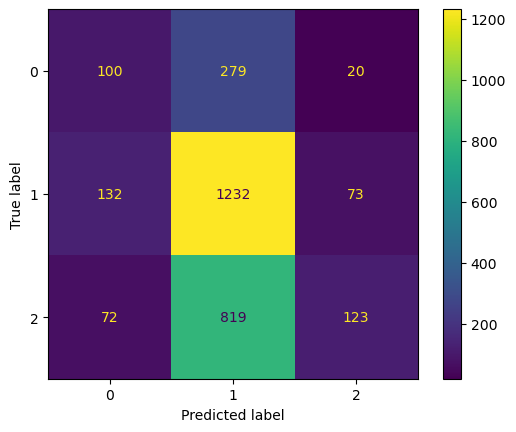

In [799]:
# Getting the combined confusion matrix for a prediction threshold of 0.45
disp = ConfusionMatrixDisplay(cf_overall_0_45.astype(int))
disp.plot()
plt.show()

And once again, we see that our Class 2 predictions are quite good, and our Class 0 predictions are not so much. Overall, we'll need to analyze exactly how much we would have made or lost had we gone in based on our model predictions, as these numbers only tell us whether or not the stock ended up closing higher or lower than the Open (or stayed roughly the same) for that particular day. This data does NOT tell us how large the difference between the two prices are.

# Evaluating Final Model Performance with the Original Test Set
***NOTE: Everything below this point is using old data and is incorrect**

# (OLD AND USING THE INCORRECT DATA SPLITS) Evaluating Final Model Performance with the Original Test Set

## Loading up hyperparameter-tuned model
We have already tuned our model, and we're just loading it back up for evaluation

In [356]:
# Loading up the previous hyperparameter-tuned LSTM long model
model_LSTM = load_model('model_LSTM_long_2025_03_24.keras')
model_LSTM.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4331 - loss: 1.0564


[1.0581820011138916, 0.43452632427215576]

## Plotting a confusion matrix for the test predictions

In [357]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM.predict(X_test)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[733, 261, 337],
       [519, 962, 337],
       [625, 607, 369]])

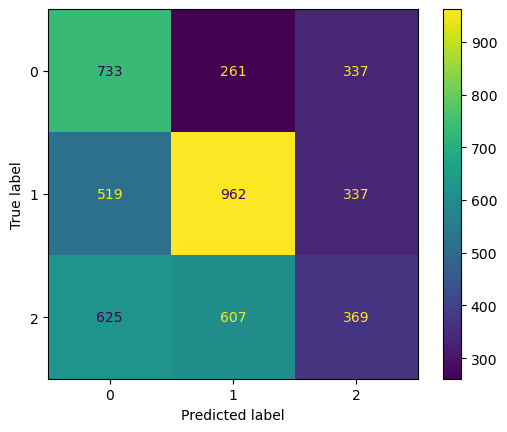

In [358]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

## Analyzing accuracy and precision metrics

In [55]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.59650303 0.44740099 0.55919854] 

Determining recall for each class:
[0.53692494 0.48621385 0.5716946 ] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


What matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its Open for a particular day, we want to know how "precise" that measurement is. Additionally, for our purposes, if our model ever predicts a class of 1 (meaning that the Close price is not expected to be significantly different from the Open price), we would be better off not going in at all. Therefore, it would not be unreasonable to only focus on the predicted labels of 0 and 2 and understand what they mean:

In [69]:
# Getting more granular precision metrics for classes 0 and 2
sum_pred_0 = np.sum(cf, axis=0)[0]
sum_pred_2 = np.sum(cf, axis=0)[2]
pred_0_true_0 = cf[0, 0] / sum_pred_0
pred_0_true_1 = cf[1, 0] / sum_pred_0
pred_0_true_2 = cf[2, 0] / sum_pred_0
pred_2_true_0 = cf[0, 2] / sum_pred_2
pred_2_true_1 = cf[1, 2] / sum_pred_2
pred_2_true_2 = cf[2, 2] / sum_pred_2

print("When predicting Class 0 (sell short):")
print(" - True Positive for Class 0:", round(pred_0_true_0, 4))
print(" - False Positive for Class 1:", round(pred_0_true_1, 4))
print(" - False Positive for Class 2:", round(pred_0_true_2, 4), '\n')

print("When predicting Class 2 (buy long):")
print(" - False Positive for Class 0:", round(pred_2_true_0, 4))
print(" - False Positive for Class 1:", round(pred_2_true_1, 4))
print(" - True Positive for Class 2:", round(pred_2_true_2, 4))

When predicting Class 0 (sell short):
 - True Positive for Class 0: 0.5965
 - False Positive for Class 1: 0.2387
 - False Positive for Class 2: 0.1648 

When predicting Class 2 (buy long):
 - False Positive for Class 0: 0.1925
 - False Positive for Class 1: 0.2483
 - True Positive for Class 2: 0.5592


When looking at the results in this manner, we see that our model actually does do a very impressive job separating the True Positives from the False Positives. If we want to translate this into real-world trading, if you put money in at 9:30am ET on any particular day for any stock in the S&P500 and you take your money out at 4:00pm ET:
 - If your model predicts that you should sell short (Class 0):
   - You have a ~60% chance to earn money, ~24% chance to break even, and ~16% chance to lose money.
 - If your model predicts that you should buy long (Class 2):
   - You have a ~56% chance to earn money, ~25% chance to break even, and ~19% chance to lose money.

For most retail traders, these odds seem to be pretty decent, and they look even better if you ignore the true label of Class 1 - since predicting either Class 0 or Class 2 and having the true label being Class 1 equates to you simply not putting money in at all (i.e., you might as well have skipped this day of trading). Looking at it from this perspective, we can calculate the following metrics:

In [73]:
# Calculating how much more likely you are to earn money over losing money
pos_chance_vs_neg_class_0 = pred_0_true_0 / (pred_0_true_0 + pred_0_true_2)
pos_chance_vs_neg_class_2 = pred_2_true_2 / (pred_2_true_2 + pred_2_true_0)
profit_factor_simple_class_0 = pred_0_true_0 / pred_0_true_2
profit_factor_simple_class_2 = pred_2_true_2 / pred_2_true_0

print("When predicting Class 0:")
print(" - Your chance of ending positive compared to negative:", round(pos_chance_vs_neg_class_0, 4))
print(" - How much more likely you are to end up positive compared to negative:", round(profit_factor_simple_class_0, 4), '\n')
print("When predicting Class 2:")
print(" - Your chance of ending positive compared to negative:", round(pos_chance_vs_neg_class_2, 4))
print(" - How much more likely you are to end up positive compared to negative:", round(profit_factor_simple_class_2, 4))

When predicting Class 0:
 - Your chance of ending positive compared to negative: 0.7836
 - How much more likely you are to end up positive compared to negative: 3.6204 

When predicting Class 2:
 - Your chance of ending positive compared to negative: 0.7439
 - How much more likely you are to end up positive compared to negative: 2.9054


As we can see, are between 2.9-3.6 times more likely to earn money than we are to lose money when using this model. It also appears that Class 0 (selling short) seems to be more promising, which might suggest that when a stock is about to slide, the signs are clearer than when the stock is about to go up.

We do want to caveat this by saying that a "true" profit factor calculation involves dividing your **total gains** by your **total losses**, which isn't what we have here. What we have is a ratio telling you how much more likely you are to earn money on any particular trade over losing money on that trade. For example, you could have 3x greater chance of earning 10 USD compared to losing 100 USD. However, your true profit factor (and expected value) would obviously be negative. Conversely, you could also have a 3x greater chance of earning 100 USD compared to losing 10 USD, which would put you way ahead.

With the model we have here, we cannot distinguish between these or any other related scenarios, and we can only say predict **whether** you will earn money or not (and not by how much). Nevertheless, the odds seem to be in our favor overall, and it would be interesting to test this with data from 2025.

## Comparing the actual softmax percents from our model predictions

In [158]:
# Getting max of the Y test prediction percentages
Y_test_max_preds = Y_test_pred_perc.max(axis=1)

# Concatenating the Y_test prediction percentages, the argmax of the predictions, and the actual Y_test values into one dataframe
full_pred_df = np.stack((Y_test_max_preds, Y_test_pred, Y_test), axis=1)
full_pred_df = pd.DataFrame(full_pred_df)
full_pred_df = full_pred_df.rename(columns={0: 'Max Predicted Percent', 1: 'Predicted Label', 2: 'True Label'})

full_pred_df.head()

,Max Predicted Percent,Predicted Label,True Label
0,0.614090,1.0,2.0
1,0.561769,1.0,0.0
2,0.689198,1.0,2.0
3,0.633958,1.0,2.0
4,0.813936,1.0,1.0


In [160]:
# Getting a column for whether the prediction was correct
full_pred_df['Correct Prediction'] = (full_pred_df['Predicted Label'] == full_pred_df['True Label'])

# Getting another column for the opposite prediction for classes 0 and 2 (e.g., predict 0 with true label of 2)
full_pred_df['Opposite Prediction'] = abs(full_pred_df['Predicted Label']-full_pred_df['True Label']) == 2

# Getting one more column for the nearest tenth percent (floor) for bucketing
full_pred_df['Percent Bucket'] = np.floor(full_pred_df['Max Predicted Percent']*10) / 10

full_pred_df.head()

,Max Predicted Percent,Predicted Label,True Label,Correct Prediction,Opposite Prediction,Percent Bucket
0,0.614090,1.0,2.0,False,False,0.6
1,0.561769,1.0,0.0,False,False,0.5
2,0.689198,1.0,2.0,False,False,0.6
3,0.633958,1.0,2.0,False,False,0.6
4,0.813936,1.0,1.0,True,False,0.8


In [161]:
# Getting a df of only the class 2 or class 0 predictions
class_0_2_pred = full_pred_df[full_pred_df['Predicted Label'] != 1.0]

class_0_2_pred.head()

,Max Predicted Percent,Predicted Label,True Label,Correct Prediction,Opposite Prediction,Percent Bucket
5,0.558908,0.0,1.0,False,False,0.5
8,0.835332,2.0,2.0,True,False,0.8
10,0.550158,2.0,0.0,False,True,0.5
11,0.537226,2.0,1.0,False,False,0.5
13,0.649960,0.0,0.0,True,False,0.6


In [180]:
# Getting a table of prediction types grouped by percent bucket (e.g., 0.4 would any softmax percent from 0.4-0.4999...)
pred_type_df = class_0_2_pred.groupby('Percent Bucket')[['Correct Prediction', 'Opposite Prediction']].sum()
pred_type_df['Total Predictions'] = class_0_2_pred.groupby('Percent Bucket')['Correct Prediction'].count()
pred_type_df = pred_type_df.rename(columns={'Correct Prediction': 'Correct Predictions', 'Opposite Prediction': 'Opposite Predictions'})
pred_type_df['Neutral Predictions'] = (pred_type_df['Total Predictions'] - pred_type_df['Opposite Predictions'] -
                                       pred_type_df['Correct Predictions'])
pred_type_df = pred_type_df[['Correct Predictions', 'Opposite Predictions', 'Neutral Predictions', 'Total Predictions']]

# Getting the percent of the correct predictions, correct and neutral predictions, neutral predictions, and opposite predictions
pred_type_df['Correct Percent'] = pred_type_df['Correct Predictions'] / pred_type_df['Total Predictions']
pred_type_df['Correct and Neutral Percent'] = (
    pred_type_df['Correct Predictions'] + pred_type_df['Neutral Predictions']) / pred_type_df['Total Predictions']
pred_type_df['Neutral Percent'] = pred_type_df['Neutral Predictions'] / pred_type_df['Total Predictions']
pred_type_df['Opposite Percent'] = pred_type_df['Opposite Predictions'] / pred_type_df['Total Predictions']

pred_type_df

,Correct Predictions,Opposite Predictions,Neutral Predictions,Total Predictions,Correct Percent,Correct and Neutral Percent,Neutral Percent,Opposite Percent
Percent Bucket,,,,,,,,
0.3,100,72,96,268,0.373134,0.731343,0.358209,0.268657
0.4,329,240,259,828,0.397343,0.710145,0.312802,0.289855
0.5,340,122,181,643,0.528771,0.810264,0.281493,0.189736
0.6,253,71,109,433,0.584296,0.836028,0.251732,0.163972
0.7,222,35,65,322,0.689441,0.891304,0.201863,0.108696
0.8,248,17,44,309,0.802589,0.944984,0.142395,0.055016
0.9,316,5,10,331,0.954683,0.984894,0.030211,0.015106


What we see from the table above is a set of prediction metrics grouped by the percent bucket. In our case, "percent bucket" is just a way to assign a max softmax prediction. For example, if the outcomes of the final softmax prediction were [0.25, 0.10, 0.65], the max (0.65) would fall in the 0.6 bucket (representing values ranging from 0.6 to 0.6999...).

We can also see that the percent of "Correct Percent" - i.e., the percent of correct predictions compared to all predictions for that bucket - increases as the percent bucket sizes increase. In fact, if the max of the softmax prediction outputs anything higher than 0.9, we have a ~95% chance to make money. Not only that, once we include the neutral percent in there, we will have a ~98% chance to either make money or break even. To better visualize the increase in "Correct Percent" as we move up the buckets, we can use a bar graph:

<Figure size 1000x600 with 0 Axes>

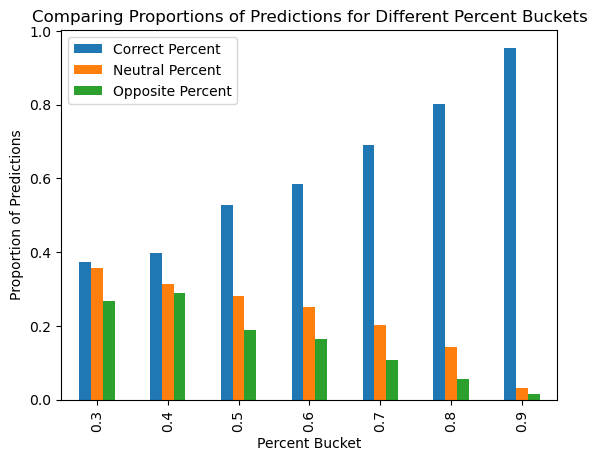

In [195]:
# Plotting a bar graph for the prediction percents
plt.figure(figsize=(10, 6))
pred_type_df[['Correct Percent', 'Neutral Percent', 'Opposite Percent']].plot(kind='bar')
plt.xlabel("Percent Bucket")
plt.ylabel("Proportion of Predictions")
plt.title("Comparing Proportions of Predictions for Different Percent Buckets")

plt.show()

Once again, we see that our chances of success increase dramatically as we move higher in percent buckets. This means that depending on our risk tolerance, we may want to only trade stocks that meet a minimum max softmax threshold. Of course, if our threshold is too high (e.g., 0.99), there might not be any stocks for us to trade.

However, in this scenario, if we choose the highest threshold we specified - 0.9 - we would still have 331 total predictions spread across 10 days. This means that for any particular day, if we put money into all the stocks that our model predicts have a 90% chance of being class 0 or class 2, we will enter ~33 stock trades that day, and we would have a 95% chance that the stocks would go the direction that's in our favor.

Realistically, this seems almost too good to be true, and we still need to account for the fact that our model only predicts whether or not a stock goes up or down (and not by how much). To see if we can actually make money based on our predictions, let's simulate what might happen if we actually put our money in based on our model's outputs.

## Comparison with majority class baseline
We could have analyzed the baseline earlier, but we wanted to get our best, final results before comparing.

For some context, our baseline predictions simply state that we should predict the majority class. In our case, the majority class looks as follows:

In [215]:
# Predicting majority class
baseline_train_counts = pd.DataFrame(Y_train).value_counts()
baseline_train_counts = pd.concat([baseline_train_counts, baseline_train_counts/len(Y_train)], axis=1)
baseline_col_names = ['Number of Predictions', 'Percent of Total']
baseline_train_counts.columns = baseline_col_names
baseline_train_counts.index.names = ['Class Prediction']

baseline_train_counts

,Number of Predictions,Percent of Total
Class Prediction,,
2,150864,0.348637
0,146677,0.338961
1,135184,0.312402


While we could do some deeper analyses into the baseline, we can see pretty clearly that if we always predict the majority Class 2 (or that the Close price will be higher than the Open price), our accuracy will only be ~35%. That's a far cry from the ~95% final accuracy we achieved above. However, once again, let's simulate real-world outcomes to compare what might truly happen.

# Simulating Real-World Outcomes Using Our Model Predictions

We know that our test data comes from the last 10 days of stock data for all 475 tickers in our dataset. Therefore, we can create a copy of just that part of the data and match the indexes from our class_0_2_pred df (with prediction types for Class 0 and 2) to find which stock we're trading on what day.

In [240]:
# Creating a copy of the original data to get the original Open and Close values and a few other metrics
stock_data_test = data.copy()
stock_data_test = stock_data_test[stock_data_test['Ticker'] != 'BIIB']  # Removing Biogen since it's missing a date
stock_data_test = stock_data_test.sort_values(by=['Date', 'Ticker'])
stock_data_test = stock_data_test.iloc[-Y_test.shape[0]:][['Ticker', 'Open', 'Close', 'GICS Sector']]
stock_data_test = stock_data_test.reset_index()

stock_data_test

,Date,Ticker,Open,Close,GICS Sector
0,2024-12-17,A,137.326181,136.208252,Health Care
1,2024-12-17,AAL,16.450001,16.719999,Other
2,2024-12-17,AAP,43.290980,44.215874,Other
3,2024-12-17,AAPL,249.805339,253.201599,Information Technology
4,2024-12-17,ABBV,168.986431,173.741592,Health Care
...,...,...,...,...,...
4745,2024-12-31,YUM,134.089996,134.160004,Consumer Discretionary
4746,2024-12-31,ZBH,105.910004,105.629997,Health Care
4747,2024-12-31,ZBRA,383.420013,386.220001,Information Technology
4748,2024-12-31,ZION,54.077518,53.829456,Other


In [254]:
# Getting the indices for the 0.9 percent buckets to match with the stock_data_test df
perc_bucket_0_9_indices = class_0_2_pred[class_0_2_pred['Percent Bucket'] == 0.9].index
stock_data_test.loc[perc_bucket_0_9_indices]

,Date,Ticker,Open,Close,GICS Sector
44,2024-12-17,AVGO,240.006934,239.588058,Information Technology
197,2024-12-17,HBAN,17.022804,16.785000,Financials
248,2024-12-17,KMI,26.123319,26.331120,Energy
252,2024-12-17,L,83.500000,83.639999,Financials
291,2024-12-17,MO,53.548636,53.097412,Consumer Staples
...,...,...,...,...,...
4443,2024-12-31,FFIV,252.820007,251.470001,Information Technology
4446,2024-12-31,FITB,42.630001,42.279999,Financials
4448,2024-12-31,FMC,48.320000,48.610001,Materials
4460,2024-12-31,GL,110.651335,111.279976,Financials


In [255]:
class_0_2_pred[class_0_2_pred['Percent Bucket'] == 0.9]

,Max Predicted Percent,Predicted Label,True Label,Correct Prediction,Opposite Prediction,Percent Bucket
44,0.926958,2.0,1.0,False,False,0.9
197,0.968510,2.0,2.0,True,False,0.9
248,0.936395,0.0,0.0,True,False,0.9
252,0.944398,2.0,2.0,True,False,0.9
291,0.998019,0.0,0.0,True,False,0.9
...,...,...,...,...,...,...
4443,0.912444,0.0,0.0,True,False,0.9
4446,0.902699,2.0,2.0,True,False,0.9
4448,0.956290,0.0,0.0,True,False,0.9
4460,0.937299,0.0,0.0,True,False,0.9


In [258]:
Y_test[-15:]

array([0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 1], dtype=int32)

In [259]:
data_small.iloc[-15:]

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,GICS Sector,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-31,2024-12-31,WST,1.403240,1.399933,1.403113,1.386494,1.393998,0.290136,0.662972,False,...,-0.480081,1.394619,1.356965,1.399956,1.388012,0.533054,2.191170,Health Care,-1.039276,0
2024-12-31,2024-12-31,WTW,1.879725,1.881788,1.881788,1.859459,1.870145,0.088615,0.512231,False,...,-0.461201,1.865676,1.852596,1.878608,1.877244,0.493595,1.460768,Financials,-0.229329,1
2024-12-31,2024-12-31,WU,1.026325,1.028264,1.031171,1.018572,1.024387,0.095763,0.189219,False,...,-0.311323,1.030617,1.036678,1.028651,1.030885,0.466490,2.366585,Other,0.094431,1
2024-12-31,2024-12-31,WY,1.446668,1.436907,1.440503,1.413275,1.432797,0.317827,0.968091,False,...,-0.198135,1.483803,1.575718,1.456755,1.501501,0.323745,2.435589,Real Estate,-0.035512,1
2024-12-31,2024-12-31,WYNN,1.244826,1.266121,1.266121,1.234830,1.243377,0.167129,0.116508,False,...,-0.068769,1.310481,1.337884,1.287830,1.310040,0.365633,2.901083,Consumer Discretionary,0.267664,1
2024-12-31,2024-12-31,XEL,1.838376,1.857182,1.857182,1.830472,1.842191,0.232014,-0.207123,False,...,-0.446453,1.849764,1.853339,1.851058,1.862017,0.441401,1.673958,Utilities,0.103780,1
2024-12-31,2024-12-31,XOM,1.694513,1.696588,1.700738,1.683980,1.687970,0.262456,0.387668,False,...,-0.304707,1.724815,1.841763,1.708735,1.751521,0.225949,1.626999,Energy,1.318641,2
2024-12-31,2024-12-31,XRAY,0.574002,0.575531,0.576753,0.560860,0.570029,0.082436,0.697057,False,...,-0.518373,0.582061,0.614350,0.576257,0.582555,0.415683,3.022167,Other,1.064957,2
2024-12-31,2024-12-31,XRX,0.863123,0.867734,0.868695,0.827374,0.856203,0.115301,0.808311,False,...,-0.341530,0.849407,0.860008,0.860588,0.854526,0.500500,4.232805,Other,-3.436418,0


In [1]:
# Need to find a way to easily get all the metrics again, and then also make sure they're scaled appropriately (so same as before)

# More Testing